# Mobile Phone Dataset Analysis

## Overview
This notebook explores a synthetic dataset of pre-owned mobile phones (Apple, Samsung, Xiaomi) to analyze how hardware specifications, device age, battery health, and physical condition impact market prices.

## Research Questions
1. **Brand vs. Battery Health:** Which brand maintains the highest average battery health in the sample?
2. **Battery Health vs. Price:** Is there a strong correlation between battery health and resale price?
3. **Age Depreciation:** How steeply does a phone's price drop as its age increases?
4. **Price Trends Over Time:** How does average resale price vary across brands for devices of different ages?

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


data = {
    'brand': [
        'Apple', 'Samsung', 'Xiaomi', 'Apple', 'Samsung', 'Xiaomi', 'Apple', 'Samsung', 'Xiaomi', 'Apple',
        'Samsung', 'Apple', 'Xiaomi', 'Samsung', 'Apple', 'Xiaomi', 'Samsung', 'Apple', 'Xiaomi', 'Samsung'
    ],
    'model': [
        'iPhone 12', 'Galaxy S21', 'Redmi Note 10', 'iPhone 13 Pro', 'Galaxy S22', '11T Pro', 'iPhone 11', 'Galaxy A52',
        'Redmi Note 11', 'iPhone 14', 'Galaxy S20', 'iPhone 13', 'Poco X3', 'Galaxy A53', 'iPhone SE 2020', '12 Lite',
        'Galaxy S23', 'iPhone 12 Pro', 'Redmi 10', 'Galaxy A32'
    ],
    'ram_gb': [4, 8, 4, 6, 8, 8, 4, 6, 4, 6, 8, 4, 6, 6, 3, 8, 8, 6, 4, 4],
    'storage_gb': [
        128, 128, 64, 256, 256, 128, 64, 128, 128, 128,
        128, 128, 128, 128, 64, 128, 256, 128, 64, 128
    ],
    'age_years': [
        3.5, 3.0, 3.0, 2.0, 2.0, 2.5, 4.0, 3.0, 2.0, 1.5,
        4.0, 2.5, 3.5, 2.0, 4.0, 1.5, 1.0, 3.0, 2.5, 3.5
    ],
    'condition': [
        'Like New', 'Excellent', 'Good', 'Like New', 'Excellent', 'Good', 'Fair', 'Excellent',
        'Good', 'Like New', 'Fair', 'Excellent', 'Fair', 'Excellent', 'Fair',
        'Like New', 'Like New', 'Excellent', 'Fair', 'Good'
    ],
    'battery_health': [
        85, 82, 78, 91, 88, 84, 75, 86, 90, 94,
        72, 87, 80, 89, 74, 93, 96, 83, 81, 79
    ],
    'price_usd': [
        350, 250, 120, 650, 420, 270, 230, 180, 140, 600,
        210, 480, 150, 220, 160, 290, 700, 430, 100, 150
    ]
}

df_phones = pd.DataFrame(data)
df_phones.head(7)

,brand,model,ram_gb,storage_gb,age_years,condition,battery_health,price_usd
0,Apple,iPhone 12,4,128,3.5,Like New,85,350
1,Samsung,Galaxy S21,8,128,3.0,Excellent,82,250
2,Xiaomi,Redmi Note 10,4,64,3.0,Good,78,120
3,Apple,iPhone 13 Pro,6,256,2.0,Like New,91,650
4,Samsung,Galaxy S22,8,256,2.0,Excellent,88,420
5,Xiaomi,11T Pro,8,128,2.5,Good,84,270
6,Apple,iPhone 11,4,64,4.0,Fair,75,230


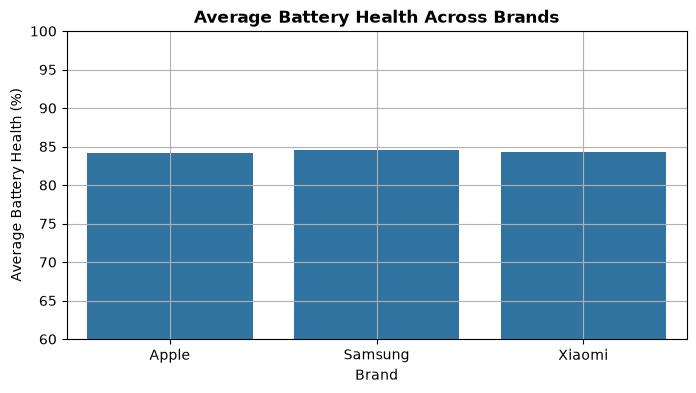

In [6]:
# 1. Average Battery Health by Brand
avg_battery = df_phones.groupby('brand')['battery_health'].mean().reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(data=avg_battery, x='brand', y='battery_health')
plt.title('Average Battery Health Across Brands', fontsize=12, fontweight='bold')
plt.xlabel('Brand')
plt.ylabel('Average Battery Health (%)')
plt.ylim(60, 100)
plt.grid()
plt.show()

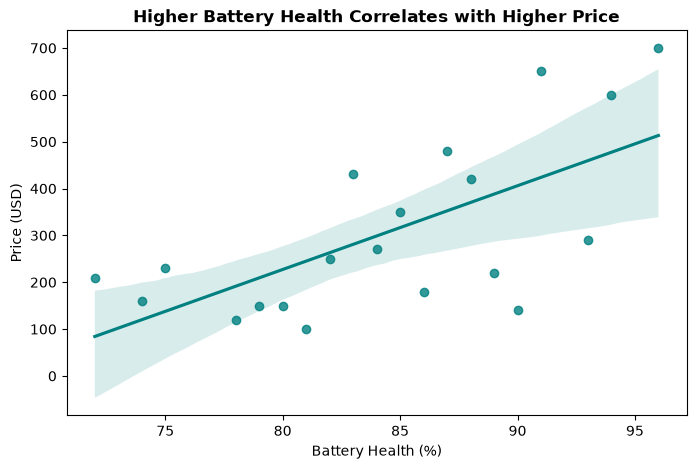

In [12]:
# 2. Battery Health vs. Price
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_phones, 
    x='battery_health', 
    y='price_usd', 
    color='teal'
)
plt.title('Higher Battery Health Correlates with Higher Price', fontsize=12, fontweight='bold')
plt.xlabel('Battery Health (%)')
plt.ylabel('Price (USD)')
plt.show()

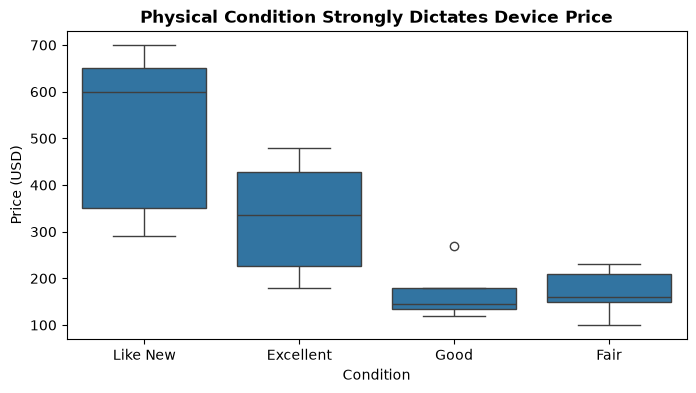

In [14]:
# 3. Price Distribution by Condition
condition_order = ['Like New', 'Excellent', 'Good', 'Fair']

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df_phones, 
    x='condition', 
    y='price_usd', 
    order=condition_order
)
plt.title('Physical Condition Strongly Dictates Device Price', fontsize=12, fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Price (USD)')
plt.show()

In [16]:
# 5. Price over time
age_brand_prices = (
    df_phones.groupby(['age_years', 'brand'])['price_usd']
    .mean()
    .reset_index()
    .sort_values(by=['age_years', 'brand'])
)

age_brand_prices

,age_years,brand,price_usd
0,1.0,Samsung,700.0
1,1.5,Apple,600.0
2,1.5,Xiaomi,290.0
3,2.0,Apple,650.0
4,2.0,Samsung,320.0
5,2.0,Xiaomi,140.0
6,2.5,Apple,480.0
7,2.5,Xiaomi,185.0
8,3.0,Apple,430.0
9,3.0,Samsung,215.0
